# Three ways of reading the PDF — pdfplumber, LightOnOCR, Docling — with gemma4:e4b

The model never sees the PDF. It sees one string per document with the formatting
marked in it — `**bold**`, `_italic_`, `++underline++` — and it cuts that string into
labelled pieces. Everything upstream of the model is *how that string is made*, and
this project has three ways:

| extractor | how it reads the page | where bold / italic / underline come from |
|---|---|---|
| **pdfplumber** | the PDF's own characters and drawn shapes | font name and size per character; a thin rectangle drawn under a word |
| **LightOnOCR** | a picture of the page, read by a vision model | the model's judgement while transcribing — asked for the markers, follows them loosely |
| **Docling** | the PDF's characters, grouped into blocks by a layout model | font name and size per word from Docling's native page cells; hyperlink rectangles; the layout model's heading label |

Same model (gemma4:e4b), same 10 documents, same prompt, same scoring. Sections:

1. What each extractor actually hands the model — marker counts per document
2. Overall score, both paths
3. Per class
4. Per document
5. Confusion matrices
6. What it adds up to


In [1]:
import os
import re
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.annotation_rules import load_method_new, resolve_new_gt_path
from dmpbridge.evaluation.evaluate import (
    LABELS, _confusion_from_match, _match_structured, compute_f1_rows, extract_gold,
    load_method, micro_prf1, resolve_old_gt_path,
)

MODEL = 'gemma4:e4b'
SAMPLES = range(1, 11)
EXTRACTORS = {'pdfplumber': 'pdfplumber', 'LightOnOCR': 'lightonocr', 'Docling': 'docling'}
TAGS = {name: P.make_tag(MODEL, ex) for name, ex in EXTRACTORS.items()}
COLOURS = {'pdfplumber': '#2a78d6', 'LightOnOCR': '#eb6834', 'Docling': '#1baf7a'}

INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})
pd.set_option('display.width', 160)

available = [name for name, tag in TAGS.items()
             if all(P.final_path(tag, n).exists() for n in SAMPLES)]
print('comparing:', ', '.join(available))


comparing: pdfplumber, LightOnOCR, Docling


## 1. What each extractor hands the model

The stage-1 text for every document, counted for the three markers. pdfplumber reads
them from the fonts, so its column is the reference for what the PDF contains.


In [2]:
def marker_counts(text):
    # pdfplumber and Docling write '** x **'; LightOnOCR writes Markdown's '**x**' and
    # '*x*' — count both spellings so the comparison is fair to it
    return (len(re.findall(r'\*\*\s?[^*\n]+?\s?\*\*', text)),
            len(re.findall(r'(?<![\w*+])_\s?[^_\n]+?\s?_(?![\w])', text))
            + len(re.findall(r'(?<![*\w])\*(?!\*)[^*\n]+?\*(?![*\w])', text)),
            len(re.findall(r'\+\+\s?[^+\n]+?\s?\+\+', text)))


def stage1(ex, n):
    p = P.extracted_path(ex, n)
    return json.loads(p.read_text(encoding='utf-8'))[0]['text'] if p.exists() else ''


rows = []
for n in SAMPLES:
    row = {'sample': n}
    for name in available:
        b, i, u = marker_counts(stage1(EXTRACTORS[name], n))
        row[f'{name} bold'] = b
        row[f'{name} italic'] = i
        row[f'{name} underline'] = u
    rows.append(row)
markers = pd.DataFrame(rows).set_index('sample')
display(markers)

# LightOnOCR writes Markdown headings (#) rather than ** for most emphasis
heads = {n: len(re.findall(r'^#+ ', stage1('lightonocr', n), re.M)) for n in SAMPLES}
print('LightOnOCR # headings per sample:', heads)


,pdfplumber bold,pdfplumber italic,pdfplumber underline,LightOnOCR bold,LightOnOCR italic,LightOnOCR underline,Docling bold,Docling italic,Docling underline
sample,,,,,,,,,
1,16,3,2,0,1,0,16,3,1
2,42,41,11,7,1,0,42,41,11
3,26,0,0,0,0,0,26,0,0
4,1,0,0,0,0,0,1,0,0
5,16,5,0,11,4,0,16,5,0
6,5,0,5,5,0,0,5,0,0
7,1,0,0,0,0,0,1,0,0
8,2,12,0,0,1,0,2,12,0
9,7,0,0,0,1,0,8,0,0


LightOnOCR # headings per sample: {1: 16, 2: 8, 3: 6, 4: 1, 5: 5, 6: 1, 7: 1, 8: 7, 9: 6, 10: 7}


**Docling's column now matches pdfplumber's on 8 of 10 documents** — the same fonts,
read by both — and differs only where an underline is a drawn line rather than a
hyperlink (samples 1, 6, 10), which Docling has no shape data for. **LightOnOCR** is
the odd one out: it writes most emphasis as `#` headings instead of `**`, marks few
italics, and never writes `++`. Its markers are a judgement, not a measurement.


## 2. Overall score

Path A scores the model's structured output against the original annotation;
Path B scores the output after the annotation rules against the revised annotation.
Compare down a column, not across.


In [3]:
S = {}
for name in available:
    df_a, conf_a, _ = load_method(TAGS[name], exclude=[])
    df_b, conf_b, _ = load_method_new(TAGS[name], exclude=[])
    m_a, m_b = micro_prf1(conf_a), micro_prf1(conf_b)
    S[name] = {'docs': len(df_a), 'precision': m_a['precision'], 'recall': m_a['recall'],
               'Path A': m_a['f1'], 'Path B': m_b['f1'],
               '_conf_a': conf_a, '_conf_b': conf_b, '_docs': df_a}
head = pd.DataFrame({k: {c: v[c] for c in ('docs', 'precision', 'recall', 'Path A', 'Path B')}
                     for k, v in S.items()}).T
head['docs'] = head['docs'].astype(int)
display(head.round(3))


,docs,precision,recall,Path A,Path B
pdfplumber,10,0.961,0.932,0.946,0.951
LightOnOCR,10,0.822,0.841,0.831,0.828
Docling,10,0.975,0.879,0.924,0.910


pdfplumber leads on both paths. Docling is 2.2 points behind on Path A with *higher*
precision — its loss is recall, and section 4 shows it is one document. LightOnOCR
trails by 13 points. (For the record: the earlier Docling extractor, which worked from
Docling's Markdown export and so had no fonts at all, scored 0.767 / 0.757 on the same
documents; reading the native cells instead is worth 16 points.)


## 3. Per class (Path A)


,support,pdfplumber,LightOnOCR,Docling
label,,,,
title,10,1.000,1.000,1.000
section.title,43,1.000,0.933,0.938
section.description,8,0.889,0.552,0.941
question.text,16,0.828,0.692,0.897
answer.text,55,0.935,0.824,0.904


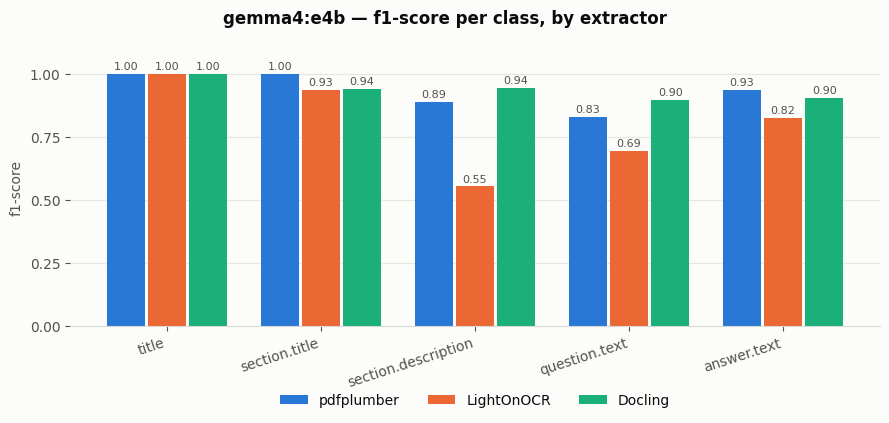

In [4]:
per = {name: compute_f1_rows(S[name]['_conf_a']).set_index('label') for name in available}
tbl = pd.DataFrame({name: per[name]['f1'] for name in available}).loc[list(LABELS)]
tbl.insert(0, 'support', per[available[0]]['support'].astype(int))
display(tbl.round(3))

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(LABELS))
w = 0.8 / max(len(available), 1)
for k, name in enumerate(available):
    vals = [per[name]['f1'].get(l, 0) for l in LABELS]
    bars = ax.bar(x + (k - (len(available) - 1) / 2) * w, vals,
                  width=w - 0.02, color=COLOURS[name], label=name)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=8, color=MUTED)
ax.set_xticks(x); ax.set_xticklabels(LABELS, rotation=18, ha='right')
ax.set_ylim(0, 1.1); ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('f1-score')
ax.grid(axis='y', color=GRID, linewidth=0.9); ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.legend(ncol=len(available), loc='upper center', bbox_to_anchor=(0.5, -0.2))
fig.suptitle(f'{MODEL} — f1-score per class, by extractor', fontweight='bold')
plt.tight_layout()
plt.show()


The two classes that separate the extractors are `question.text` and
`section.description` — the labels that depend on an inline bold label being split
from its answer, and on italic instruction text being recognised. Docling is ahead
of pdfplumber on both; it gives back that lead on `section.title` and `answer.text`,
which is sample 6 (next section).


## 4. Per document (Path A)

One score per document per extractor, so the average cannot hide a single bad
document — or a single good one.


In [5]:
def doc_f1(name, n):
    # same computation as scripts/inspect_sample.py, so the numbers agree
    gold = extract_gold(resolve_old_gt_path(n))
    records, no_gold = _match_structured(P.structured_path(TAGS[name], n), gold)
    return micro_prf1(_confusion_from_match(records, no_gold))['f1']


docs = pd.DataFrame({name: {n: doc_f1(name, n) for n in SAMPLES} for name in available})
docs.index.name = 'sample'
display(docs.round(3))
for name in available:
    print(f'{name:<11} perfect on', [n for n in SAMPLES if docs.loc[n, name] == 1.0])


,pdfplumber,LightOnOCR,Docling
sample,,,
1,1.000,1.000,1.000
2,0.818,0.640,0.870
3,1.000,0.963,1.000
4,1.000,1.000,1.000
5,0.786,0.538,0.923
6,1.000,1.000,0.154
7,1.000,1.000,1.000
8,1.000,0.533,1.000
9,1.000,1.000,1.000


pdfplumber  perfect on [1, 3, 4, 6, 7, 8, 9, 10]
LightOnOCR  perfect on [1, 4, 6, 7, 9, 10]
Docling     perfect on [1, 3, 4, 7, 8, 9, 10]


Read the Docling column against pdfplumber's: identical on seven documents, **better
on samples 2 and 5**, and one collapse — sample 6, whose five headings are underlined
with a drawn line and nothing else. pdfplumber sees the line as a rectangle; Docling's
data has no rectangles, so those headings arrive as plain text and the document falls
apart. LightOnOCR gets sample 6 right (it *sees* the underline in the image and calls it
bold) but loses on 2, 5 and 8, where italic paragraphs and inline labels come back
plain.


## 5. Confusion matrices (Path B)

Rows are the true label, columns what the model called it; the last column is
blocks the model never produced. Percentages are of the row.


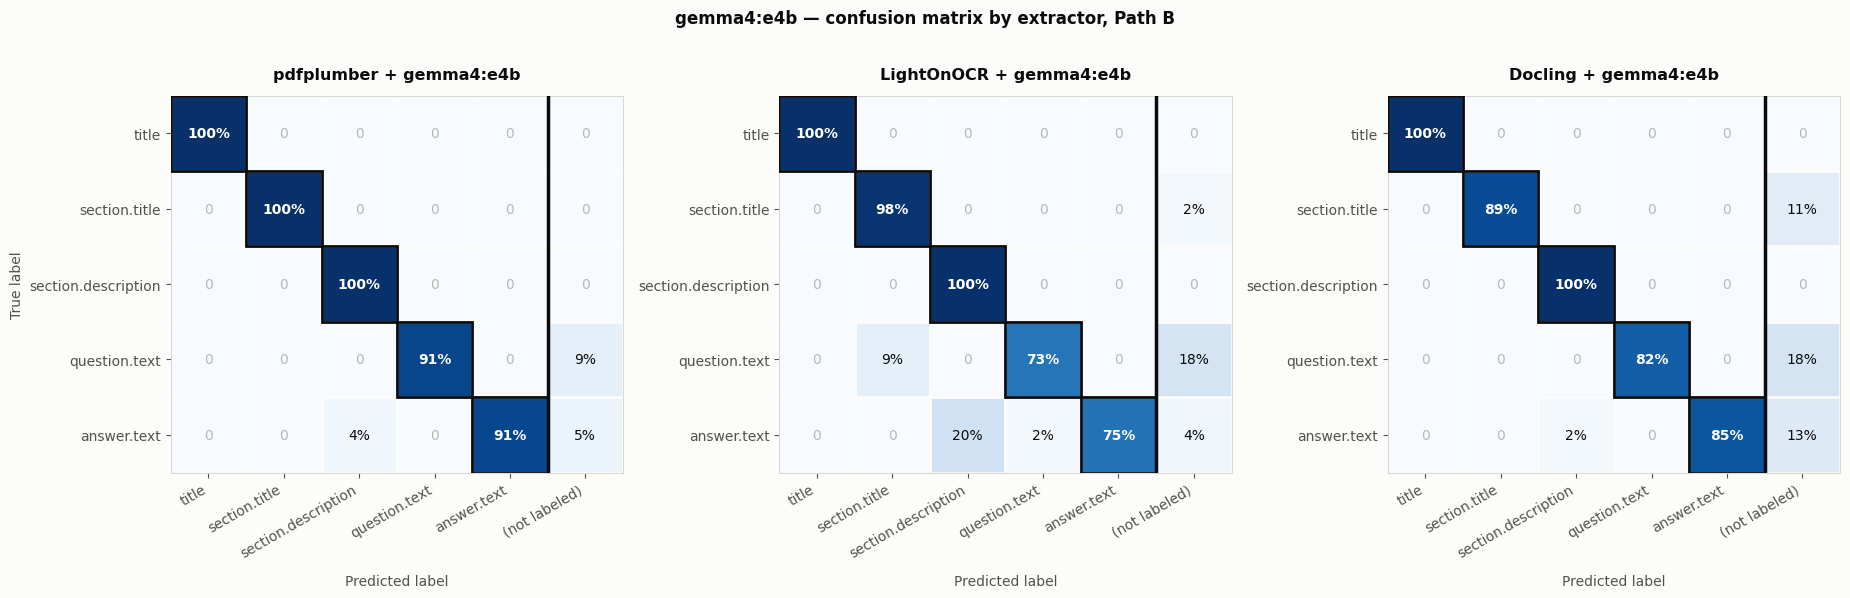

In [6]:
COLS = list(LABELS) + ['(not labeled)']
KEYS = list(LABELS) + ['__missed__']


def pooled_conf(tag):
    pooled = defaultdict(lambda: defaultdict(int))
    for n in SAMPLES:
        gold = extract_gold(resolve_new_gt_path(n), dedup_question_title=False)
        records, no_gold = _match_structured(P.final_path(tag, n), gold,
                                             dedup_question_title=False)
        for k, row in _confusion_from_match(records, no_gold).items():
            for kk, v in row.items():
                pooled[k][kk] += v
    return pooled


def build_pct(conf):
    pct = np.zeros((len(LABELS), len(KEYS)))
    for i, t in enumerate(LABELS):
        total = sum(conf.get(t, {}).values())
        for j, key in enumerate(KEYS):
            if total:
                pct[i, j] = conf.get(t, {}).get(key, 0) / total
    return pct


fig, axes = plt.subplots(1, len(available), figsize=(6.2 * len(available), 5.6), squeeze=False)
for ax, name in zip(axes[0], available):
    cm = build_pct(pooled_conf(TAGS[name]))
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    for i in range(len(LABELS)):
        for j in range(len(KEYS)):
            v = cm[i, j]
            ax.text(j, i, f'{v:.0%}' if v else '0', ha='center', va='center', fontsize=10,
                    fontweight='bold' if i == j else 'normal',
                    color='#b9b9b4' if v == 0 else ('white' if v > 0.55 else INK))
    ax.set_title(f'{name} + {MODEL}', pad=12)
    ax.set_xticks(range(len(COLS))); ax.set_xticklabels(COLS, rotation=30, ha='right')
    ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.set_xticks(np.arange(-.5, len(COLS), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
    ax.grid(which='minor', color=SURFACE, linewidth=2); ax.tick_params(which='minor', length=0)
    for k in range(len(LABELS)):
        ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False, edgecolor=INK, linewidth=2, zorder=5))
    ax.axvline(len(LABELS) - 0.5, color=INK, linewidth=2.5, zorder=6)
axes[0][0].set_ylabel('True label')
fig.suptitle(f'{MODEL} — confusion matrix by extractor, Path B', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 6. What it adds up to

- **The markers are the whole game.** Same model, same prompt, same text; the score
  tracks how faithfully the extractor reports bold, italic and underline. pdfplumber
  and Docling now read the same fonts and produce the same markers on 8 of 10
  documents, and they score within 2 points of each other. LightOnOCR guesses at the
  markers from a picture and is 13 points back.
- **The remaining pdfplumber–Docling gap is one document.** Sample 6's drawn
  underlines are the only signal pdfplumber has that Docling structurally cannot
  get. Everywhere else Docling is level or ahead — it finds 13 of the 16 real
  questions to pdfplumber's 12, and does better on the two documents (2, 5) with
  the most inline labels and instruction text.
- **Recommendation stands: pdfplumber + gemma4:e4b.** It has the highest score, no
  structural blind spot on this corpus, no layout model to run, and sub-second
  extraction. Docling is a close second with things pdfplumber lacks — block
  boundaries, a page and position for every block, a confidence per block — and
  would be the choice if those mattered or if the documents had real tables.
  LightOnOCR is the only one of the three that can read a scanned page.
